# Model Training — Baselines

Trains 1D CNN classifiers (10-class: normal + {inner_race, ball, outer_race} × {0.007", 0.014", 0.021"}) with no domain adaptation, giving two reference points for later transfer-learning work:

- **Baseline 1 — source-only**: a model trained on one load's full train split, evaluated on a *different* load's test split. The floor — raw accuracy lost purely to domain shift.
- **Baseline 2 — target-only, scarce data**: a separately trained model per load, using only `TARGET_LABELED_FRAC` (10%) of that load's training windows *per class*, evaluated on the same load's test split. Shows what's achievable while ignoring the source domain entirely, under the realistic assumption that target labels are scarce — this is the story a full-data target-only model doesn't tell (it turns out ~1300 windows/load is already enough to nearly saturate this task in-domain, so it isn't a useful "scarce" reference point; that full-data ceiling baseline has been dropped here).

**8 models total**: one "full" model per load (used only for baseline 1's cross-domain evaluation) + one "scarce" model per load (baseline 2). Note: 10% of the *smallest* class (`inner_race_0.014` at load 0, 12 training windows) rounds down to a single training example — worth keeping in mind when interpreting load-0-as-target results.

Both share the same architecture (embedding extractor + label predictor, kept as separate modules so a later domain-adaptation method can reuse the embedding) and the same windows (`data/windows_by_load.pkl`, raw `DE_time`, 4096 samples).

In [1]:
import os
import pickle
import random
from itertools import permutations

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report

DATA_DIR = "data"
WINDOW_SIZE = 4096
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

with open(os.path.join(DATA_DIR, "windows_by_load.pkl"), "rb") as f:
    windows_by_load = pickle.load(f)

LOADS = sorted(windows_by_load.keys())
print(f"Loads: {LOADS}")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

Using device: cuda
Loads: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## Labels, splits, and data loading

10 classes: `normal` + {`inner_race`, `ball`, `outer_race`} × {0.007", 0.014", 0.021"}. Outer-race clock position (6:00/3:00/12:00) is pooled into the diameter class, not treated as a separate label — which means `outer_race_0.007`/`outer_race_0.021` have ~3x as many windows as the other classes (3 positions each, vs. 1 for everything else). The training loop below uses class-weighted loss to compensate.

In [2]:
def label_for_item(item):
    if item["category"] == "normal":
        return "normal"
    return f"{item['fault_location']}_{item['fault_diameter_in']:.3f}"


CLASS_NAMES = sorted({
    label_for_item(item)
    for load_windows in windows_by_load.values()
    for items in load_windows.values()
    for item in items
})
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
N_CLASSES = len(CLASS_NAMES)
print(f"{N_CLASSES} classes: {CLASS_NAMES}")


def make_splits(source_load: int, target_load: int) -> dict:
    """Build the 4-bucket domain-adaptation split for one (source_load -> target_load) pair."""
    return {
        "source_train": windows_by_load[source_load]["train"],
        "source_test": windows_by_load[source_load]["test"],
        "target_labeled": windows_by_load[target_load]["train"],
        "target_test": windows_by_load[target_load]["test"],
    }


class WindowDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        x = torch.tensor(item["window"], dtype=torch.float32).unsqueeze(0)  # (1, WINDOW_SIZE): 1 input channel
        y = CLASS_TO_IDX[label_for_item(item)]
        return x, y


def class_weights(items, device=DEVICE):
    """Inverse-frequency class weights for CrossEntropyLoss, to offset the outer_race 3x imbalance."""
    counts = np.zeros(N_CLASSES)
    for item in items:
        counts[CLASS_TO_IDX[label_for_item(item)]] += 1
    weights = counts.sum() / (N_CLASSES * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device)

10 classes: ['ball_0.007', 'ball_0.014', 'ball_0.021', 'inner_race_0.007', 'inner_race_0.014', 'inner_race_0.021', 'normal', 'outer_race_0.007', 'outer_race_0.014', 'outer_race_0.021']


## Model: 1D CNN, embedding extractor + label predictor

Kept as two separate modules (not just separate layers within one `forward`) so a later domain-adaptation method can attach to `embedding_extractor`'s output directly — e.g. computing MMD between source/target embeddings, or adding a gradient-reversal domain classifier on top of it — without touching the classification head.

In [3]:
class EmbeddingExtractor(nn.Module):
    """Raw DE_time window -> fixed-size embedding. Wide first-layer kernel (common for raw-vibration
    1D CNNs) downsamples quickly and captures broadband content before the narrower layers refine it."""

    def __init__(self, embedding_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=16, padding=24), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # collapses to length 1 regardless of exact conv output length
        )
        self.fc = nn.Linear(64, embedding_dim)

    def forward(self, x):
        x = self.conv(x).squeeze(-1)  # (batch, 64)
        return self.fc(x)             # (batch, embedding_dim)


class LabelPredictor(nn.Module):
    """Embedding -> class logits."""

    def __init__(self, embedding_dim=128, n_classes=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, z):
        return self.net(z)


class CNNClassifier(nn.Module):
    def __init__(self, embedding_dim=128, n_classes=N_CLASSES):
        super().__init__()
        self.embedding_extractor = EmbeddingExtractor(embedding_dim)
        self.label_predictor = LabelPredictor(embedding_dim, n_classes)

    def forward(self, x):
        return self.label_predictor(self.embedding_extractor(x))

In [4]:
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3


def train_model(model, train_items, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=DEVICE, verbose=False):
    model.to(device)
    train_loader = DataLoader(WindowDataset(train_items), batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights(train_items, device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
        epoch_loss = total_loss / len(train_loader.dataset)
        history.append(epoch_loss)
        if verbose:
            print(f"epoch {epoch + 1}/{epochs}: loss={epoch_loss:.4f}")
    return history


@torch.no_grad()
def evaluate_model(model, items, device=DEVICE):
    model.eval()
    loader = DataLoader(WindowDataset(items), batch_size=BATCH_SIZE)
    y_true, y_pred = [], []
    for x, y in loader:
        preds = model(x.to(device)).argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy())
        y_pred.extend(preds)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [5]:
from collections import defaultdict

TARGET_LABELED_FRAC = 0.10  # baseline 2: fraction of each class's training windows to keep


def subsample_frac_per_class(items, frac, seed=SEED, min_per_class=1):
    """Deterministically keep `frac` of each class's windows (at least min_per_class, if available)."""
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for item in items:
        by_class[label_for_item(item)].append(item)

    subsampled = []
    for class_items in by_class.values():
        class_items = class_items.copy()
        rng.shuffle(class_items)
        n_keep = min(len(class_items), max(min_per_class, round(len(class_items) * frac)))
        subsampled.extend(class_items[:n_keep])
    return subsampled

## Train the 8 models

One "full" model per load (trained on the full train split, used only for baseline 1's cross-domain evaluation) and one "scarce" model per load (baseline 2, trained on `TARGET_LABELED_FRAC` of each class's windows). No pair-level retraining — the 12-pair table below is built by evaluating these 8 already-trained models against each load's test split, not by training anything new.

In [6]:
full_models = {}    # per load: trained on the full train split — used only for baseline 1 (cross-domain)
scarce_models = {}  # per load: trained on TARGET_LABELED_FRAC of the train split — baseline 2 (in-domain)
baseline2_eval = {}

for load in LOADS:
    train_items = windows_by_load[load]["train"]
    test_items = windows_by_load[load]["test"]

    set_seed(SEED)
    full_model = CNNClassifier()
    train_model(full_model, train_items)
    full_models[load] = full_model

    scarce_items = subsample_frac_per_class(train_items, TARGET_LABELED_FRAC)
    set_seed(SEED)
    scarce_model = CNNClassifier()
    train_model(scarce_model, scarce_items)
    scarce_models[load] = scarce_model
    baseline2_eval[load] = evaluate_model(scarce_model, test_items)

    print(f"load={load}: n_train_full={len(train_items)}, n_train_scarce={len(scarce_items)} "
          f"({TARGET_LABELED_FRAC:.0%}/class) | baseline2 (in-domain) acc={baseline2_eval[load]['accuracy']:.3f}")

load=0: n_train_full=536, n_train_scarce=56 (10%/class) | baseline2 (in-domain) acc=0.906


load=1: n_train_full=1322, n_train_scarce=131 (10%/class) | baseline2 (in-domain) acc=0.814


load=2: n_train_full=1326, n_train_scarce=134 (10%/class) | baseline2 (in-domain) acc=0.839


load=3: n_train_full=1323, n_train_scarce=133 (10%/class) | baseline2 (in-domain) acc=0.752


In [7]:
MODELS_DIR = "models"  # project-root-relative, sibling of data/ — not nested inside it
os.makedirs(MODELS_DIR, exist_ok=True)

for load in LOADS:
    torch.save(full_models[load].state_dict(), os.path.join(MODELS_DIR, f"baseline1_full_load{load}.pt"))
    torch.save(scarce_models[load].state_dict(), os.path.join(MODELS_DIR, f"baseline2_scarce_load{load}.pt"))

print(f"Saved {2 * len(LOADS)} checkpoints to {MODELS_DIR}/")

Saved 8 checkpoints to models/


## Build the 12-pair comparison table

Baseline 1 is evaluated per pair (cross-domain: `full_models[source_load]` on `target_load`'s test split). Baseline 2 doesn't depend on `source_load` at all, so its value is just looked up from the per-load evaluations above and repeated across the 3 pairs that share a given `target_load`.

In [8]:
results = []

for source_load, target_load in permutations(LOADS, 2):
    eval1 = evaluate_model(full_models[source_load], windows_by_load[target_load]["test"])

    results.append({
        "source_load": source_load,
        "target_load": target_load,
        "baseline1_source_only_acc": eval1["accuracy"],
        "baseline1_source_only_f1": eval1["macro_f1"],
        "baseline2_target_scarce_acc": baseline2_eval[target_load]["accuracy"],
        "baseline2_target_scarce_f1": baseline2_eval[target_load]["macro_f1"],
    })
    print(f"{source_load}->{target_load}: baseline1 acc={eval1['accuracy']:.3f} f1={eval1['macro_f1']:.3f}")

results_df = pd.DataFrame(results)

0->1: baseline1 acc=0.615 f1=0.466
0->2: baseline1 acc=0.668 f1=0.511
0->3: baseline1 acc=0.494 f1=0.321
1->0: baseline1 acc=0.617 f1=0.533
1->2: baseline1 acc=0.919 f1=0.854
1->3: baseline1 acc=0.904 f1=0.841


2->0: baseline1 acc=0.398 f1=0.228


2->1: baseline1 acc=0.839 f1=0.771
2->3: baseline1 acc=0.696 f1=0.619


3->0: baseline1 acc=0.570 f1=0.483
3->1: baseline1 acc=0.780 f1=0.689
3->2: baseline1 acc=0.860 f1=0.851


In [9]:
results_path = os.path.join(DATA_DIR, "baseline_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Saved to {results_path}\n")

print("Baseline 1 (source-only), averaged over all 12 pairs — genuinely varies per pair:")
display(results_df[["baseline1_source_only_acc", "baseline1_source_only_f1"]].agg(["mean", "std"]))

# Baseline 2 doesn't depend on source_load, so its value is repeated 3x in results_df (once per
# pair sharing that target_load) — average over the 4 unique loads, not the 12 expanded rows,
# or every load gets triple-counted and the reported variance understates the truth.
per_load_summary = pd.DataFrame({
    "baseline2_target_scarce_acc": {load: baseline2_eval[load]["accuracy"] for load in LOADS},
    "baseline2_target_scarce_f1": {load: baseline2_eval[load]["macro_f1"] for load in LOADS},
})
print("\nBaseline 2, averaged over the 4 unique loads (not the 12 expanded pair-rows):")
per_load_summary.agg(["mean", "std"])

Saved to data/baseline_results.csv

Baseline 1 (source-only), averaged over all 12 pairs — genuinely varies per pair:


,baseline1_source_only_acc,baseline1_source_only_f1
mean,0.696602,0.597274
std,0.166806,0.209584



Baseline 2, averaged over the 4 unique loads (not the 12 expanded pair-rows):


,baseline2_target_scarce_acc,baseline2_target_scarce_f1
mean,0.827494,0.769053
std,0.063985,0.067310


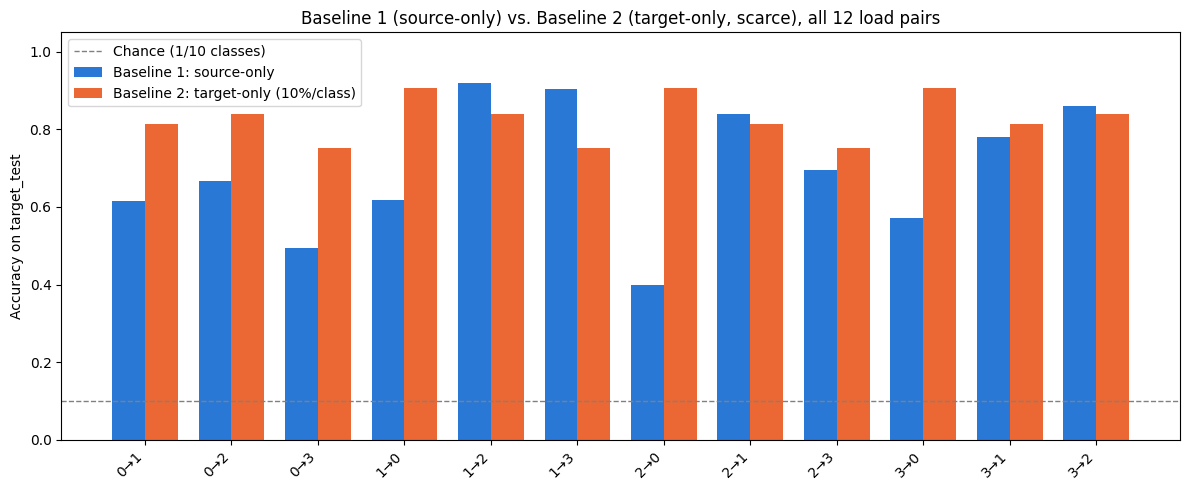

In [10]:
import matplotlib.pyplot as plt

pair_labels = [f"{r.source_load}→{r.target_load}" for r in results_df.itertuples()]
x = np.arange(len(pair_labels))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - bar_width / 2, results_df["baseline1_source_only_acc"], bar_width,
       label="Baseline 1: source-only", color="#2a78d6")
ax.bar(x + bar_width / 2, results_df["baseline2_target_scarce_acc"], bar_width,
       label=f"Baseline 2: target-only ({TARGET_LABELED_FRAC:.0%}/class)", color="#eb6834")
ax.axhline(1 / N_CLASSES, color="gray", linewidth=1, linestyle="--", label="Chance (1/10 classes)")

ax.set_xticks(x)
ax.set_xticklabels(pair_labels, rotation=45, ha="right")
ax.set_ylabel("Accuracy on target_test")
ax.set_ylim(0, 1.05)
ax.set_title("Baseline 1 (source-only) vs. Baseline 2 (target-only, scarce), all 12 load pairs")
ax.legend()
plt.tight_layout()
plt.show()

## Per-class detail for one example pair

The aggregate accuracy/F1 above can hide which fault classes each baseline actually confuses. Looking at 0→1 with a full `classification_report` shows where the domain gap (baseline 1) and the label-scarcity gap (baseline 2) actually bite — reusing the already-trained models above, no retraining needed.

In [11]:
example_source, example_target = 0, 1

eval_b1 = evaluate_model(full_models[example_source], windows_by_load[example_target]["test"])
eval_b2 = baseline2_eval[example_target]

print(f"=== Baseline 1: source-only ({example_source}->{example_target}) ===")
print(classification_report(eval_b1["y_true"], eval_b1["y_pred"], target_names=CLASS_NAMES, zero_division=0))

print(f"=== Baseline 2: target-only, {TARGET_LABELED_FRAC:.0%}/class (load {example_target}) ===")
print(classification_report(eval_b2["y_true"], eval_b2["y_pred"], target_names=CLASS_NAMES, zero_division=0))

=== Baseline 1: source-only (0->1) ===
                  precision    recall  f1-score   support

      ball_0.007       0.56      1.00      0.72        23
      ball_0.014       0.65      0.87      0.74        23
      ball_0.021       0.00      0.00      0.00        23
inner_race_0.007       0.00      0.00      0.00        23
inner_race_0.014       0.00      0.00      0.00        23
inner_race_0.021       0.92      1.00      0.96        23
          normal       0.32      0.96      0.48        23
outer_race_0.007       1.00      0.67      0.80        69
outer_race_0.014       0.00      0.00      0.00        23
outer_race_0.021       1.00      0.93      0.96        69

        accuracy                           0.61       322
       macro avg       0.44      0.54      0.47       322
    weighted avg       0.60      0.61      0.58       322

=== Baseline 2: target-only, 10%/class (load 1) ===
                  precision    recall  f1-score   support

      ball_0.007       0.43      1.